In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df= pd.read_csv("../dataset/cleaned_hormuz_trade.csv")
print(df.head())


         date    vessel_name       mmsi    flag  trade_tier transit_status  \
0  2026-03-01  MarchVessel_1  100000001   India  Privileged         Passed   
1  2026-03-01  MarchVessel_2  100000002    Iran  Privileged         Passed   
2  2026-03-01  MarchVessel_3  100000003    Iran  Privileged         Passed   
3  2026-03-02  MarchVessel_4  100000004  Greece       Taxed         Passed   
4  2026-03-02  MarchVessel_5  100000005    Iran  Privileged         Passed   

   toll_usd rerouted  commodity  destination  ... days_delayed  \
0         0       No    Various  Global Port  ...            0   
1         0       No  Crude Oil       Hidden  ...            0   
2         0       No  Crude Oil       Hidden  ...            0   
3   2000000       No    Various  Global Port  ...            0   
4         0       No  Crude Oil       Hidden  ...            0   

   extra_fuel_tonnes  reroute_penalty_usd  total_transit_cost_usd  \
0                  0                    0                   40000

In [2]:
#Analyze trade volume by continent
continent_trade = df.groupby("continent")["total_transit_cost_usd"].sum().sort_values(ascending=False)

print("Trade Volume by Continent:")
print(continent_trade)
print("\nTotal Trade Volume:", continent_trade.sum())

Trade Volume by Continent:
continent
Asia             1210514300
Europe            845897400
North America     379159700
Africa            266577400
Oceania           195862800
Eurasia             6802500
Name: total_transit_cost_usd, dtype: int64

Total Trade Volume: 2904814100


In [3]:
#Countries with highest trade dependency 
print("COUNTRIES WITH HIGHEST TRADE DEPENDENCY")
country_trade = df.groupby("flag")["total_transit_cost_usd"].sum().sort_values(ascending=False)
print(country_trade.head(5))

COUNTRIES WITH HIGHEST TRADE DEPENDENCY
flag
Turkey     408809800
India      276289900
Liberia    266577400
Norway     246796100
Israel     244596500
Name: total_transit_cost_usd, dtype: int64


In [4]:
#High-risk economic zones
print("HIGH RISK ECONOMIC ZONES")
high_risk = df.groupby("destination").agg({
    "total_asset_value_at_risk_usd": "sum",
}).sort_values("total_asset_value_at_risk_usd", ascending=False)
print(high_risk.head(6))

HIGH RISK ECONOMIC ZONES
                total_asset_value_at_risk_usd
destination                                  
Hidden/Private                   163645000000
Singapore                         71765000000
Houston                           70580000000
Mumbai                            68705000000
Rotterdam                         67135000000
Ningbo                            61990000000


In [5]:
#Trade imbalance patterns
print("TRADE IMBALANCE PATTERNS")
imbalance = df.groupby("flag").agg({
    "total_transit_cost_usd": "sum",
    "estimated_cargo_value_usd": "sum",
    "days_delayed": "mean"
})
imbalance["cost_cargo_ratio"] = imbalance["total_transit_cost_usd"] / (imbalance["estimated_cargo_value_usd"] + 1)
imbalance = imbalance.sort_values("cost_cargo_ratio", ascending=False)
print(imbalance.head(5))

TRADE IMBALANCE PATTERNS
                  total_transit_cost_usd  estimated_cargo_value_usd  \
flag                                                                  
Greece                         178750700                 7990000000   
UAE                            234943100                10970000000   
Liberia                        266577400                13130000000   
India                          276289900                14100000000   
Marshall Islands               195862800                10020000000   

                  days_delayed  cost_cargo_ratio  
flag                                              
Greece                2.482759          0.022372  
UAE                   2.500000          0.021417  
Liberia               3.111111          0.020303  
India                 2.350515          0.019595  
Marshall Islands      4.000000          0.019547  


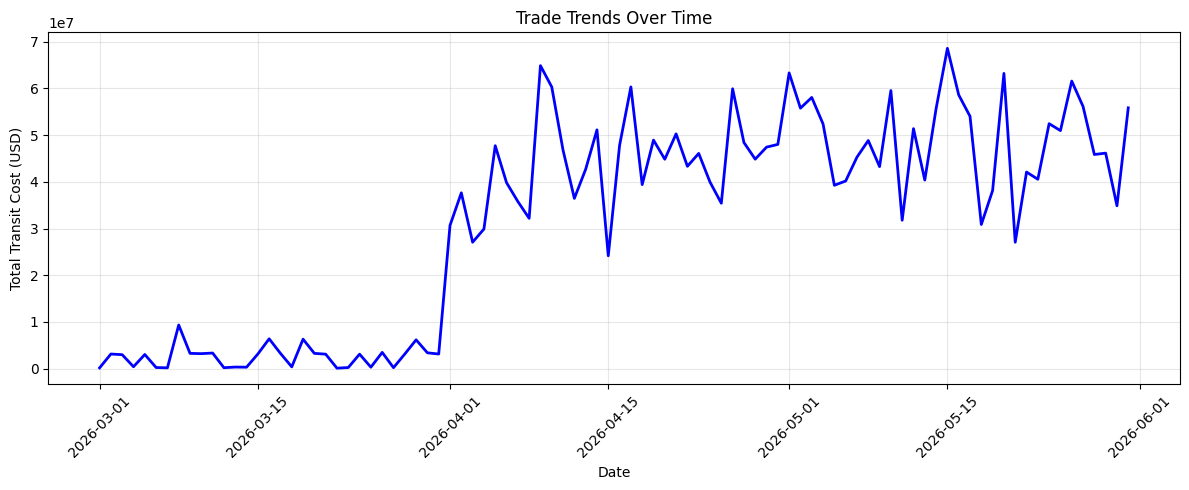

In [6]:
#Line Plot → Trade trends over time 
import os
df["date"] = pd.to_datetime(df["date"])

daily_trade = df.groupby("date")["total_transit_cost_usd"].sum()

plt.figure(figsize=(12,5))

plt.plot(daily_trade.index,
         daily_trade.values,
         linewidth=2,
         color='blue')

plt.title("Trade Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Total Transit Cost (USD)")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# os.makedirs("../outputs/charts", exist_ok=True)
plt.savefig("../outputs/charts/trade_trends_overtime.png")
plt.tight_layout()
plt.show()

In [4]:
#Create dashboards using Plotly 
import plotly.express as px
risk_zones = df.groupby("destination").agg({
    "total_asset_value_at_risk_usd": "sum"
}).reset_index()
risk_zones.columns = ["destination", "asset_at_risk"]
risk_zones = risk_zones.sort_values("asset_at_risk", ascending=False)

fig3 = px.pie(risk_zones, names="destination", values="asset_at_risk", title="High-Risk Economic Zones Distribution",
              labels={"asset_at_risk": "Asset at Risk (USD)"})
fig3.write_html("../outputs/charts/higrisk_zone_distribution.html")
fig3.show()

In [8]:
# Build interactive visualizations 
trade_trend = df.groupby("date")["total_transit_cost_usd"].sum().reset_index()
fig2 = px.bar(trade_trend, x="date", y="total_transit_cost_usd", title="Trade Trends Over Time (Bar Chart)",
              labels={"date": "Date", "total_transit_cost_usd": "Daily Transit Cost (USD)"}, color="total_transit_cost_usd",
              color_continuous_scale="Greens")
fig2.write_html("../outputs/charts/trade_trends_overtime.html")
fig2.show()